# Testing (U)OT while Max Normalizing the Cost Matrix
Other implementations of OT seem to divide the cost matrix by it's maximum value, seemingly stablizing OT. To test the effects, we'll perform the same OT analyses as before, but with this optimization included.

## Imports

In [ ]:
# Enabling fast reload
%load_ext autoreload
%autoreload 2

# Importing
import sys
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from pathlib import Path
sys.path.append('/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Scripts')
from hicdatautils import import_cool_dir, fetch_region, get_cool_name, bin_contact_map, hic_ot_bulk, dist_weights

# Setting data directory
sc_dir = '/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Data/sc_data'
save_dir = '/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Generated Data/Single-to-single/sc_uot_clustering/OT/CostMatrixNormalization'

## Helper Functions

In [2]:
def map_cell_types(data: pd.DataFrame, cell_type_map: pd.DataFrame):
    '''
        Transforms file name to file name comparisons in a pandas dataframe
        to a long format where each comparison has its own row, specifying inter
        or intra cell type of interest interactions.

        This function assusming formatting used in this notebook.

        Parameters
        ----------
        data : pd.DataFrame
            File name to file name dataframe of comparisons (SCC or OT).
        cell_type_map : pd.DataFrame
            Dataframe mapping file names to cell types.

        Returns
        -------
        data_long : pd.DataFrame
            A long format version of data with cell type information.
    '''

    # Mapping file to type
    type_lookup = cell_type_map.set_index("cell_name")["cell_type"]

    # Long format
    data_long = data.reset_index().rename(columns={"index": "row_file"})
    data_long = data_long.melt(id_vars="row_file",
                        var_name="col_file",
                        value_name="value")
    # Mapping celltypes
    data_long["row_cell_type"] = data_long["row_file"].map(type_lookup)
    data_long["col_cell_type"] = data_long["col_file"].map(type_lookup)

    # Inter and intra
    data_long["relationship"] = (
        data_long["row_cell_type"] == data_long["col_cell_type"]
        ).map({True: "intra", False: "inter"})

    return data_long

def generate_ot_data(source_cell_type: str, gamma: float=None, res: int=1, thres: int=95, reg_m: float|None=None, cell_count: int=20):
    '''
        Generates the OT data needed for the approach taken here

        This function is very specific to this notebook.

        Parameters
        ----------
        source_cell_type : str
            The cell type to be compared to all other cell types.
        gamma : float
            Distance scaling parameter.
            Default = None, uses no distance scaling.
        res : int
            Resolution to bin the data to in Mb.
            Default = 8.
        thres : int
            Threshold to use for the data.
            Default = 90.
        reg_m : float
            Unbalanced parameter to use.
            Default = None, uses balanced OT.
        cell_count : int
            The top number of cells to be used.
            Default = 20.

        Returns
        -------
        ot_results_long : pd.DataFrame
            Long format pandas dataframe with the desired results.
    '''
    ### Importing Data ###    
    # Metadata
    metadata = pd.read_csv(sc_dir+"/cell_types.tsv", sep='\t')
    sampled_files = (
        metadata.groupby('cell_type')
                .apply(lambda x: x.sample(
                    n=min(len(x), cell_count),
                    replace=False,
                    random_state=42
                ))
                .reset_index(drop=True)
    )
    targets = list(sampled_files["cell_name"])
    sources = list(sampled_files[sampled_files["cell_type"] == source_cell_type]["cell_name"])

    # Coolers
    target_clrs = import_cool_dir(sc_dir, include=targets)
    source_clrs = import_cool_dir(sc_dir, include=sources)

    ### Performing OT ###
    # Saving directory
    ot_save_dir = '/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Generated Data/Single-to-single/sc_uot_clustering/OT/CostMatrixNormalization'

    # Prepping data
    target_chr1s = []
    target_names = []

    for clr in target_clrs:
        target_chr1s.append(fetch_region(clr, "chr1"))
        target_names.append(get_cool_name(clr))

    source_chr1s = []
    source_names = []

    for clr in source_clrs:
        source_chr1s.append(fetch_region(clr, "chr1"))
        source_names.append(get_cool_name(clr))
    
    # Distance weighing
    if gamma is not None:
        target_chr1s_weighed = []
        for chr1 in target_chr1s:
            target_chr1s_weighed.append(dist_weights(chr1, gamma=gamma))

        source_chr1s_weighed = []
        for chr1 in source_chr1s:
            source_chr1s_weighed.append(dist_weights(chr1, gamma=gamma))
    else:
        target_chr1s_weighed = target_chr1s
        source_chr1s_weighed = source_chr1s


    # Binning
    target_chr1s_binned = []
    for chr1 in target_chr1s_weighed:
        target_chr1s_binned.append(bin_contact_map(chr1, res))

    source_chr1s_binned = []
    for chr1 in source_chr1s_weighed:
        source_chr1s_binned.append(bin_contact_map(chr1, res))

    # OT
    ot_results_list = []
    if reg_m is None:
        ot_results_list = hic_ot_bulk(source_chr1s_binned, target_chr1s_binned, thres, "percentile", "sum")
    else:
        ot_results_list = hic_ot_bulk(source_chr1s_binned, target_chr1s_binned, thres, "percentile", "max", unbalanced=reg_m)

    # Transform to dataframe
    ot_results_df = pd.DataFrame(ot_results_list, index=source_names, columns=target_names)

    # Saving
    if reg_m is None:
        ot_results_df.to_csv(f'{ot_save_dir}/balanced_{source_cell_type}_cluster_{res}mb_{thres}_{cell_count}_γ={gamma}.csv')
    else:
        ot_results_df.to_csv(f'{ot_save_dir}/unbalanced_reg_m={reg_m}_{source_cell_type}_cluster_{res}mb_{thres}_{cell_count}_γ={gamma}.csv')

    ### Transforming to long format ###
    ot_results_long = map_cell_types(ot_results_df, sampled_files)

    return ot_results_long

def load_ot_results_long(folder: str, res: int, thres: int, cell_count: int, gamma: float = None, reg_m : float|None = None):
    '''
        Loads all csv files corresponding to OT results
        in the given folder.

        This function is very specific to this notebook.

        Parameters
        ----------
        folder : str
            Path to folder that is to be imported.
        res : int
            Resolution used for analysis.
        thres : int
            Threshold used for analysis.
        cell_count : int
            Number of cells used for analysis.
        gamma : float
            Distance scaling parameter.
            Default = None, looks for unscaled data.
        reg_m : float
            Unbalanced parameter used.
            Default = None, looks for balanced data.
        
        Returns
        -------
        ot_df_long : pd.Dataframe
            Long form dataframe with combined data from all
            OT results.
    '''
    folder = Path(folder)
    
    # Storage dictonary
    ot_dfs = []

    # Regex patterns
    cc = re.escape(str(cell_count))

    #if gamma is None:
    #    pattern = re.compile(
    #        rf"^(.*?)_type_clustering_ot_{res}mb_{thres}_{cell_count}\.csv$"
    #    )
    #else:
    
    if reg_m is None:
        pattern = re.compile(
            rf"^balanced_(.*?)_cluster_{res}mb_{thres}_{cell_count}_γ={gamma}\.csv$"
        )
    else:
        pattern = re.compile(
            rf"^unbalanced_reg_m={reg_m}_(.*?)_cluster_{res}mb_{thres}_{cell_count}_γ={gamma}\.csv$"
        )

    for file in folder.glob("*.csv"):
        name = file.name

        m = pattern.match(name)
        if m:
            df = pd.read_csv(file, index_col=0)
            ot_dfs.append(df)

    # Covert to long and concatenate
    metadata = pd.read_csv(sc_dir+"/cell_types.tsv", sep='\t')
    ot_dfs_long = []
    for df in ot_dfs:
        ot_dfs_long.append(map_cell_types(df, metadata))
    
    ot_df_long = pd.concat(ot_dfs_long)

    return ot_df_long

def distribution_plot(data: pd.DataFrame, ax, reg_m: float|None=None):
    '''
        Plots the distribution of the provided dataframe to
        the provided Axes object.

        Function is very specific to this notebook.

        Parameters
        ----------
        data : pd.DataFrame
            Data to be plotted.
        ax
            Axes object to plot to.
        reg_m : float
            Unbalanced parameter used.
            Default = None, used balanced OT.
    '''
    # Setting order
    order = ["inter", "intra"]

    # Stripplot
    sns.stripplot(
    data=data,
    x="relationship",
    y="value",
    order=order,
    hue="relationship",
    dodge=False,
    jitter=True,
    alpha=0.05,
    palette={
        "inter": "#1f77b4",
        "intra": "#ff7f0e"
    },
    ax=ax
    )

    # Violin plot
    sns.violinplot(
        data=data,
        x="relationship",
        y="value",
        order=order,
        inner=None,
        color="lightgray",
        cut=0,
        ax=ax
    )

    ax.set_ylim(bottom=0)
    ax.set_ylabel("OT Loss")
    if reg_m is None:
        ax.set_title("Balanced OT")
    else:
        ax.set_title(f"UOT (reg_m={reg_m})")
    return

def generate_clustering_heatmap(data: pd.DataFrame, ax, reg_m: float|None=None):
    '''
        Generates a heatmap between cell types for the data generated
        in this notebook.

        Function is specific to this notebook.

        Parameters
        ----------
        data : pd.DataFrame
            Long format dataframe with cell-to-cell comparisons.
        ax
            Axes object to plot to.
        reg_m : float
            Used reg_m value for unbalanced methods.
            Default = None, assumes balanced method.
    '''
    # Calculating means per cell type
    mean_matrix = data.groupby(
        ['row_cell_type', 'col_cell_type']
    )["value"].mean()

    # Prepping for generating heatmap
    heatmap_data = mean_matrix.unstack()

    # Generating heatmap
    sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap='viridis', ax=ax)
    if reg_m is None:
        ax.set_title("Balanced OT")
    else:
        ax.set_title(f"UOT (reg_m={reg_m})")
    return

## Generating Data

In [3]:
### 1 Mb, 95% threshold, Balanced ###
    # Getting all cell types
metadata = pd.read_csv(sc_dir+"/cell_types.tsv", sep='\t')
cell_types = metadata["cell_type"].unique()

for ct in cell_types:
    generate_ot_data(ct, res=1, thres=95)

/var/folders/pf/6xtc7fx5435c3f0dbwrdl5tc0000gn/T/ipykernel_63540/921517068.py:77: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(
/var/folders/pf/6xtc7fx5435c3f0dbwrdl5tc0000gn/T/ipykernel_63540/921517068.py:77: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(
/var/folders/pf/6xtc7fx5435c3f0dbwrdl5tc0000gn/T/ipykernel_63540/921517068.py:77: FutureWarning: DataFrameGrou

In [4]:
### 1 Mb, 95% threshold, unbalanced ###
    # Setting reg_m values
reg_ms = [0.1, 1, 10]

    # Getting all cell types
metadata = pd.read_csv(sc_dir+"/cell_types.tsv", sep='\t')
cell_types = metadata["cell_type"].unique()

    # Looping over reg_ms
for reg_m in reg_ms:
    print("Started calculating for reg_m =", reg_m)
    for ct in cell_types:
        generate_ot_data(ct, res=1, thres=95, reg_m=reg_m)

Started calculating for reg_m = 0.1


/var/folders/pf/6xtc7fx5435c3f0dbwrdl5tc0000gn/T/ipykernel_63540/921517068.py:77: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(
/var/folders/pf/6xtc7fx5435c3f0dbwrdl5tc0000gn/T/ipykernel_63540/921517068.py:77: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(
/var/folders/pf/6xtc7fx5435c3f0dbwrdl5tc0000gn/T/ipykernel_63540/921517068.py:77: FutureWarning: DataFrameGrou

Started calculating for reg_m = 1


/var/folders/pf/6xtc7fx5435c3f0dbwrdl5tc0000gn/T/ipykernel_63540/921517068.py:77: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(
/var/folders/pf/6xtc7fx5435c3f0dbwrdl5tc0000gn/T/ipykernel_63540/921517068.py:77: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(
/var/folders/pf/6xtc7fx5435c3f0dbwrdl5tc0000gn/T/ipykernel_63540/921517068.py:77: FutureWarning: DataFrameGrou

Started calculating for reg_m = 10


/var/folders/pf/6xtc7fx5435c3f0dbwrdl5tc0000gn/T/ipykernel_63540/921517068.py:77: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(
/var/folders/pf/6xtc7fx5435c3f0dbwrdl5tc0000gn/T/ipykernel_63540/921517068.py:77: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(
/var/folders/pf/6xtc7fx5435c3f0dbwrdl5tc0000gn/T/ipykernel_63540/921517068.py:77: FutureWarning: DataFrameGrou

## Loading Data

In [5]:
### Loading all data ###
unbalanced_01 = load_ot_results_long(save_dir, 1, 95, 20, reg_m=0.1)
unbalanced_1 = load_ot_results_long(save_dir, 1, 95, 20, reg_m=1)
unbalanced_10 = load_ot_results_long(save_dir, 1, 95, 20, reg_m=10)

## Visualizing

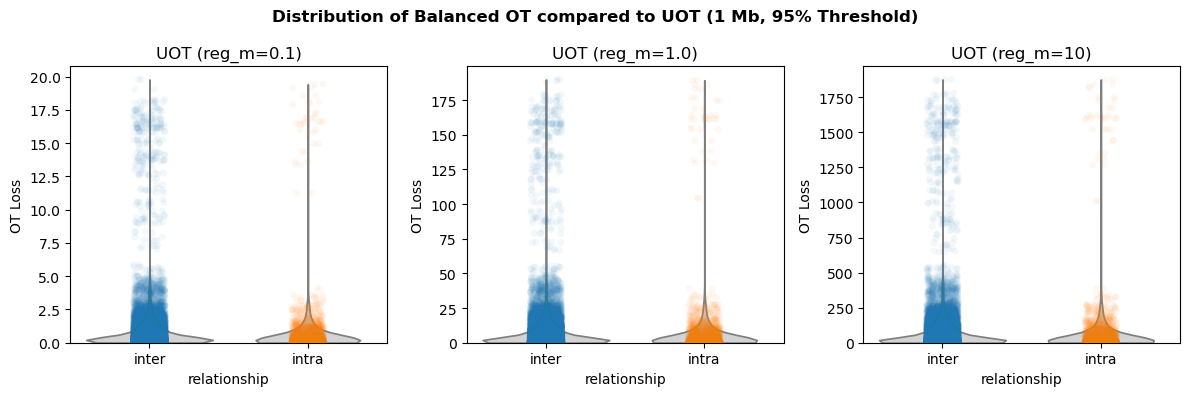

In [7]:
### Visualizing Data Distributions ###
reg_m_list = [0.1, 1.0, 10]
data_list = [unbalanced_01, unbalanced_1, unbalanced_10]

    # Initializing figure
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
axes = ax.flatten()

    # Adding subpanels
for i, (reg_m, data) in enumerate(zip(reg_m_list, data_list)):
    distribution_plot(data, axes[i], reg_m)

    # Adding titles
plt.suptitle("Distribution of Balanced OT compared to UOT (1 Mb, 95% Threshold)", fontweight="bold")
plt.tight_layout()